# Benchmark Analysis: CVDV vs Bosonic-Qiskit vs qcvdv

Load saved JSON results and generate comparison plots with log scale.

## 1. Import Required Libraries

In [21]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Notebook display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

## 2. Load Result Files

In [22]:
# Set up paths
current_dir = Path('.')
legacy_results_dir = current_dir / 'results'
campaign_root = legacy_results_dir / 'perlmutter_runs'
images_dir = current_dir / 'images'
images_dir.mkdir(parents=True, exist_ok=True)

# Discover per-run outputs written by run.sh sbatch campaigns.
result_files = sorted(campaign_root.glob('*/runs/*/benchmark_results.txt'))
legacy_file = legacy_results_dir / 'benchmark_results.txt'
if not result_files and legacy_file.exists():
    result_files = [legacy_file]

all_results = []
for result_file in result_files:
    try:
        with open(result_file, 'r') as f:
            payload = json.load(f)
        payload['_source_file'] = str(result_file)
        all_results.append(payload)
    except Exception as exc:
        print(f"[WARN] Failed to read {result_file}: {exc}")

if all_results:
    print(f"✓ Loaded {len(all_results)} result file(s)")
    dv_values = sorted({int(r.get('config', {}).get('dv_qubits', -1)) for r in all_results if r.get('config', {}).get('dv_qubits', None) is not None})
    print(f"  DV values present: {dv_values}")
    selected_dv = dv_values[0] if dv_values else None
    print(f"  Selected DV for plotting: {selected_dv}")
    print(f"  First file: {all_results[0].get('_source_file')}")
else:
    selected_dv = None
    print(f"✗ No result files found under {campaign_root}")
    print(f"  Expected pattern: <campaign>/runs/<tag>/benchmark_results.txt")

✓ Loaded 16 result file(s)
  DV values present: [2, 3, 4, 6]
  Selected DV for plotting: 2
  First file: results/perlmutter_runs/20260521_090208_jobs4_runs10_warmup2/runs/dv2__cv4/benchmark_results.txt


## 3. Parse and Structure Data

In [23]:
# Extract and organize benchmark data from all loaded runs.
if not all_results:
    raise RuntimeError('No benchmark result files available. Run run.sh first.')

# Optional DV filter. Set to an int (e.g., 4) to view one DV only; keep None to plot all DVs.
selected_dv = None

from collections import defaultdict

pair_results = []
for results in all_results:
    dv_q = results.get('config', {}).get('dv_qubits', None)
    if dv_q is None:
        continue
    dv_q = int(dv_q)
    if selected_dv is not None and dv_q != int(selected_dv):
        continue
    pair_results.append((dv_q, results))

if not pair_results:
    raise RuntimeError('No runs available after applying DV filter.')

# Aggregate means keyed by (dv, cv) pairs.
cvdv_acc = defaultdict(list)
bosonic_acc = defaultdict(list)
qcvdv_acc = defaultdict(lambda: defaultdict(list))

# Keep latest detailed payload per (dv, cv) key for component breakdown plotting.
cvdv_data = {}
bosonic_data = {}
qcvdv_data = defaultdict(dict)

for dv_q, results in pair_results:
    current_cvdv_data = results.get('cvdv', {})
    for cv_q_str, data in current_cvdv_data.items():
        cv_q = int(cv_q_str)
        pair = (dv_q, cv_q)
        if data.get('mean_ms') is not None:
            cvdv_acc[pair].append(float(data['mean_ms']))
        cvdv_data[pair] = data

    current_bosonic_data = results.get('bosonic', {})
    for cv_q_str, data in current_bosonic_data.items():
        cv_q = int(cv_q_str)
        pair = (dv_q, cv_q)
        if data.get('mean_ms') is not None:
            bosonic_acc[pair].append(float(data['mean_ms']))
        bosonic_data[pair] = data

    current_qcvdv_data = results.get('qcvdv', {})
    for method, method_data in current_qcvdv_data.items():
        for cv_q_str, data in method_data.items():
            cv_q = int(cv_q_str)
            pair = (dv_q, cv_q)
            if data.get('mean_ms') is not None:
                qcvdv_acc[method][pair].append(float(data['mean_ms']))
            qcvdv_data[method][pair] = data

cvdv_times = {pair: float(np.mean(vals)) for pair, vals in cvdv_acc.items() if vals}
bosonic_times = {pair: float(np.mean(vals)) for pair, vals in bosonic_acc.items() if vals}
qcvdv_times = {
    method: {pair: float(np.mean(vals)) for pair, vals in method_vals.items() if vals}
    for method, method_vals in qcvdv_acc.items()
}

all_pairs = sorted(
    set(cvdv_times.keys())
    | set(bosonic_times.keys())
    | set(pair for method_vals in qcvdv_times.values() for pair in method_vals.keys()),
    key=lambda x: (x[0], x[1])
)

dv_values = sorted({dv for dv, _ in all_pairs})
cv_values = sorted({cv for _, cv in all_pairs})
print(f"DV values in plot: {dv_values}")
print(f"CV sizes in plot: {cv_values}")
print(f"Pairs plotted: {len(all_pairs)}")
print(f"qcvdv methods: {list(qcvdv_times.keys())}")
for method in qcvdv_times:
    method_pairs = sorted(qcvdv_times[method].keys(), key=lambda x: (x[0], x[1]))
    print(f"  {method}: {method_pairs}")

DV values in plot: [2, 3, 4, 6]
CV sizes in plot: [4, 5, 6, 7, 8, 10]
Pairs plotted: 16
qcvdv methods: ['dense_matrix_gpu']
  dense_matrix_gpu: [(2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (6, 10)]


## 4. Generate and Save Plots as PDFs

### 4.1 Total Runtime Comparison (Log Scale)

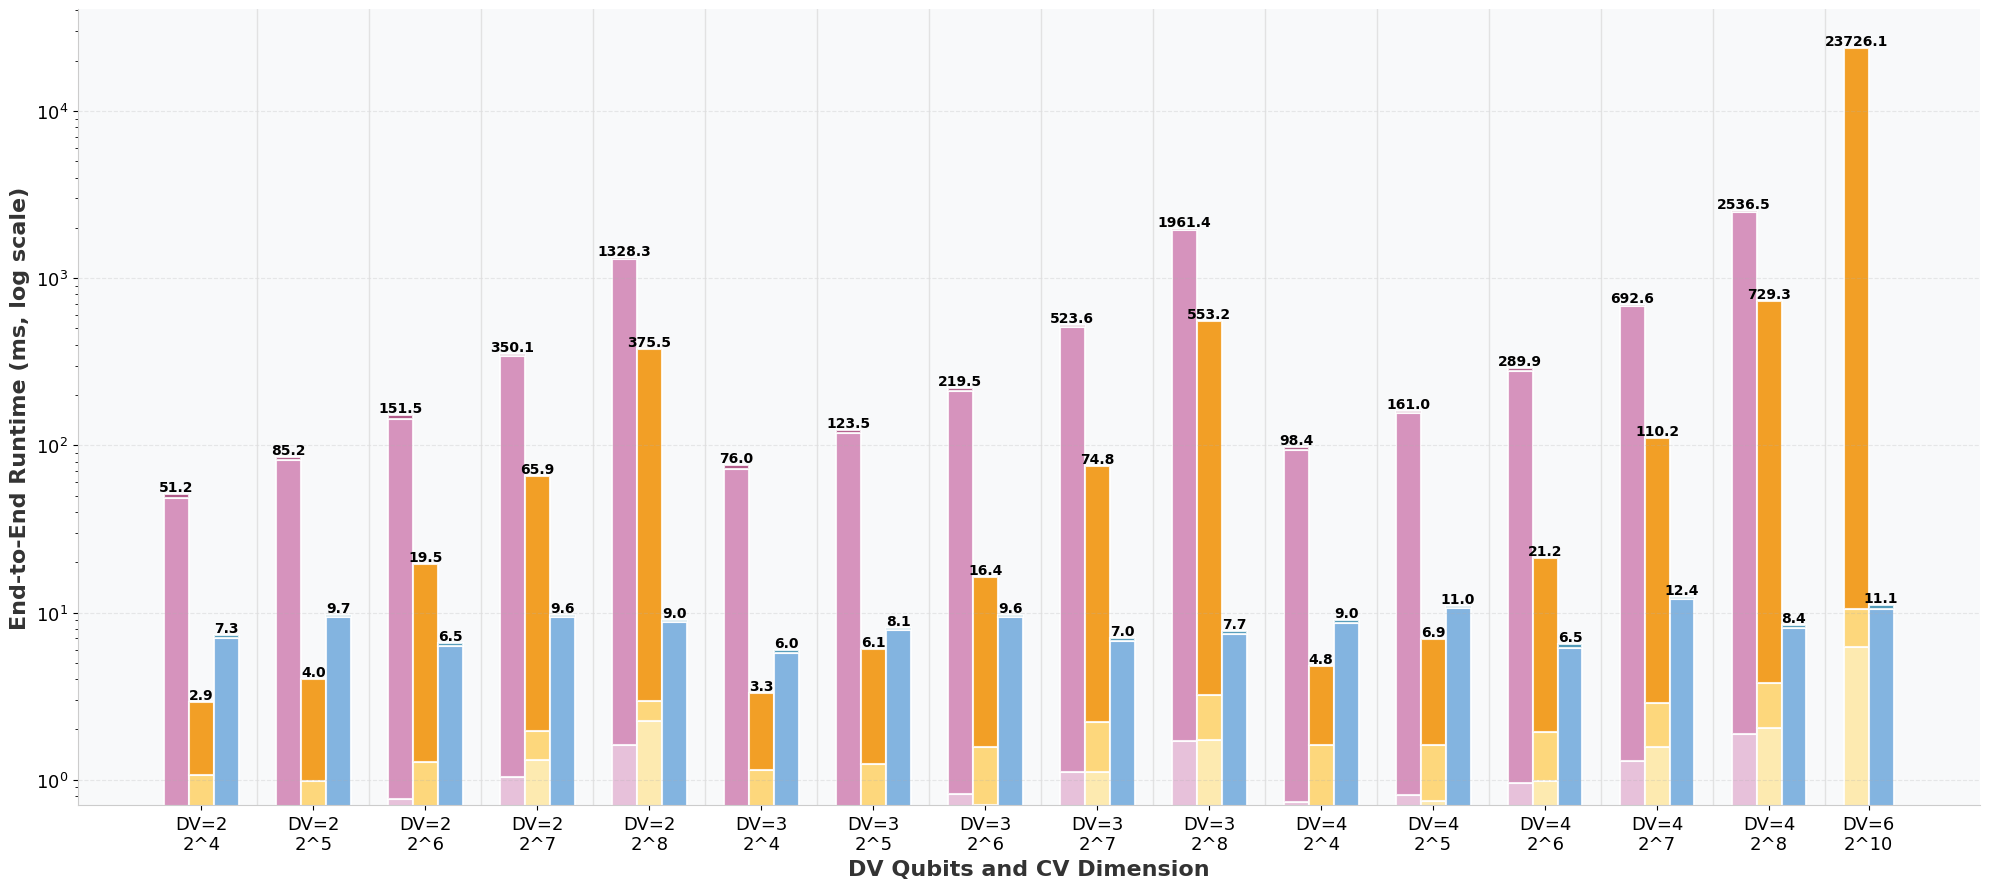

✓ Saved: images/comparison_log_scale.pdf


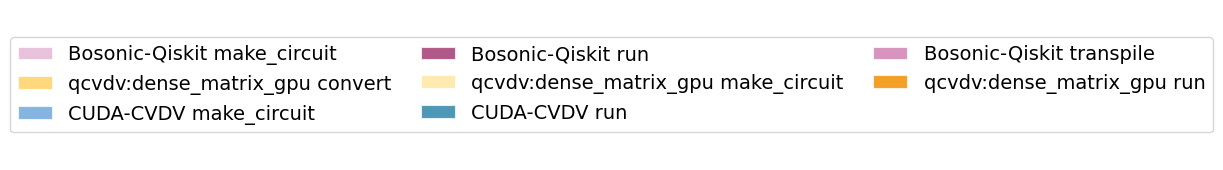

✓ Saved: images/legend.pdf


In [ ]:
# Generate comparison plot (total runtime, log scale)
cvdv_make_circuit_c = '#6FA8DC'
cvdv_run_c = '#2E86AB'
bosonic_make_circuit_c = '#E5B8D5'
bosonic_transpile_c = '#D081B3'
bosonic_run_c = '#A23B72'
qcvdv_make_circuit_palette = ['#FFE8A3', '#FCDDBB', '#FFE3B3', '#F7E1A3', '#FCE5B3']
qcvdv_convert_palette = ['#FFD166', '#F4A261', '#F6BD60', '#E9C46A', '#FAC05E']
qcvdv_run_palette = ['#F18F01', '#1B998B', '#C73E1D', '#6A4C93', '#3A86FF']
qcvdv_run_split_colors = {
    'matrix_generation': '#5B8E7D',
    'apply': '#7B6D8D',
}

width = 0.8
fig, ax = plt.subplots(figsize=(20, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

# Build grouped bar configurations by (DV, CV) pair
bar_configs = []
bar_segments = []
x_positions = []
group_centers = []
group_labels = []
group_boundaries = []
bar_spacing = 0.8
group_gap = 1.2
current_x = 0.0

pairs_by_dv = defaultdict(list)
for pair in all_pairs:
    pairs_by_dv[pair[0]].append(pair)

for dv_q in sorted(pairs_by_dv.keys()):
    for cv_q in sorted(pairs_by_dv[dv_q], key=lambda x: x[1]):
        _, cv_q = cv_q
        pair = (dv_q, cv_q)
        group_positions = []
        group_entries = []

        bosonic_res = bosonic_data.get(pair)
        if bosonic_res is not None:
            make_circuit_ms = float(bosonic_res.get('make_circuit_mean_ms', 0.0))
            transpile_ms = float(bosonic_res.get('transpile_mean_ms', 0.0))
            run_ms = float(bosonic_res.get('run_mean_ms', bosonic_times.get(pair, 0.0)))
            group_entries.append((
                'Bosonic',
                [
                    ('Bosonic-Qiskit make_circuit', make_circuit_ms, bosonic_make_circuit_c),
                    ('Bosonic-Qiskit transpile', transpile_ms, bosonic_transpile_c),
                    ('Bosonic-Qiskit run', run_ms, bosonic_run_c)
                ]
            ))

        for method_idx, method in enumerate(sorted(qcvdv_times.keys())):
            if qcvdv_times[method].get(pair) is not None:
                qcvdv_res = qcvdv_data.get(method, {}).get(pair, {})
                make_circuit_c = qcvdv_make_circuit_palette[method_idx % len(qcvdv_make_circuit_palette)]
                convert_c = qcvdv_convert_palette[method_idx % len(qcvdv_convert_palette)]
                run_c = qcvdv_run_palette[method_idx % len(qcvdv_run_palette)]
                make_circuit_ms = float(qcvdv_res.get('make_circuit_mean_ms', 0.0))
                convert_ms = float(qcvdv_res.get('convert_mean_ms', 0.0))
                run_ms = float(qcvdv_res.get('run_mean_ms', qcvdv_times[method][pair]))

                run_split_keys = ['matrix_generation', 'apply', 'make_circuit', 'transfer', 'cache_hit', 'other']
                run_split_values = [
                    float(qcvdv_res.get('run_make_circuit_mean_ms', 0.0)) if k == 'make_circuit'
                    else float(qcvdv_res.get(f'run_{k}_mean_ms', 0.0))
                    for k in run_split_keys
                ]
                has_run_split = any((f'run_{k}_mean_ms' in qcvdv_res) for k in ['matrix_generation', 'apply', 'transfer', 'cache_hit', 'other']) or ('run_make_circuit_mean_ms' in qcvdv_res)

                if has_run_split:
                    qcvdv_segments = [
                        (f'qcvdv:{method} make_circuit', make_circuit_ms, make_circuit_c),
                        (f'qcvdv:{method} convert', convert_ms, convert_c),
                    ]
                    qcvdv_segments.extend(
                        (f'qcvdv:{method} run:{k}', v, qcvdv_run_split_colors[k])
                        for k, v in zip(run_split_keys, run_split_values)
                    )
                else:
                    qcvdv_segments = [
                        (f'qcvdv:{method} make_circuit', make_circuit_ms, make_circuit_c),
                        (f'qcvdv:{method} convert', convert_ms, convert_c),
                        (f'qcvdv:{method} run', run_ms, run_c),
                    ]

                group_entries.append((
                    f'qcvdv:{method}',
                    qcvdv_segments
                ))

        cvdv_res = cvdv_data.get(pair)
        if cvdv_res is not None:
            make_circuit_ms = float(cvdv_res.get('make_circuit_mean_ms', 0.0))
            run_ms = float(cvdv_res.get('run_mean_ms', cvdv_times.get(pair, 0.0)))
            group_entries.append((
                'CVDV',
                [
                    ('CUDA-CVDV make_circuit', make_circuit_ms, cvdv_make_circuit_c),
                    ('CUDA-CVDV run', run_ms, cvdv_run_c)
                ]
            ))

        if not group_entries:
            continue

        for lib, segments in group_entries:
            bar_configs.append((lib, dv_q, cv_q))
            bar_segments.append(segments)
            x_positions.append(current_x)
            group_positions.append(current_x)
            current_x += bar_spacing

        group_centers.append(float(np.mean(group_positions)))
        group_labels.append(f'DV={dv_q}\n2^{cv_q}')
        group_boundaries.append(group_positions[-1] + (bar_spacing + group_gap) / 2)
        current_x += group_gap

# Plot bars
bars = []
for x_pos, segments in zip(x_positions, bar_segments):
    bottom = 0.0
    total_height = 0.0
    top_bar = None
    for segment_label, segment_value, segment_color in segments:
        top_bar = ax.bar(x_pos, segment_value, width, bottom=bottom, color=segment_color, alpha=0.85,
                         edgecolor='white', linewidth=1.5)[0]
        bottom += segment_value
        total_height += segment_value
    bars.append((top_bar, total_height))

for bar, total_height in bars:
    ax.text(bar.get_x() + bar.get_width()/2., total_height,
            f'{total_height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_map = {}
for segments in bar_segments:
    for label, _, color in segments:
        if label not in legend_map:
            legend_map[label] = color

ordered_backends = ['Bosonic-Qiskit'] + [f'qcvdv:{m}' for m in sorted(qcvdv_times.keys())] + ['CUDA-CVDV']
backend_groups = {backend: [] for backend in ordered_backends}
for label in legend_map.keys():
    if label.startswith('Bosonic-Qiskit'):
        backend_groups['Bosonic-Qiskit'].append(label)
    elif label.startswith('qcvdv:'):
        backend_name = label.split(' ', 1)[0]
        if backend_name in backend_groups:
            backend_groups[backend_name].append(label)
    elif label.startswith('CUDA-CVDV'):
        backend_groups['CUDA-CVDV'].append(label)

for backend in backend_groups:
    backend_groups[backend] = sorted(backend_groups[backend])

legend_cols = max(1, len(ordered_backends))
max_rows = max((len(v) for v in backend_groups.values()), default=0)
ordered_labels = []
for row in range(max_rows):
    for backend in ordered_backends:
        labels = backend_groups[backend]
        if row < len(labels):
            ordered_labels.append(labels[row])

legend_elements = [
    Patch(facecolor=legend_map[label], alpha=0.85, edgecolor='white', linewidth=1.5, label=label)
    for label in ordered_labels
]

ax.set_ylabel('End-to-End Runtime (ms, log scale)', fontsize=16, fontweight='bold', color='#333')
ax.set_xlabel('DV Qubits and CV Dimension', fontsize=16, fontweight='bold', color='#333')
ax.set_yscale('log')
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels, fontsize=13)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
for boundary in group_boundaries[:-1]:
    ax.axvline(boundary, color='#DDDDDD', linewidth=1.0, alpha=0.8)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()

comparison_pdf = images_dir / 'comparison_log_scale.pdf'
fig.savefig(comparison_pdf, format='pdf', bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {comparison_pdf}")
plt.close(fig)

legend_rows = int(np.ceil(len(legend_elements) / legend_cols))
legend_height = max(1.4, 0.45 * legend_rows + 0.6)
legend_fig, legend_ax = plt.subplots(figsize=(14, legend_height))
legend_ax.axis('off')
legend = legend_ax.legend(
    handles=legend_elements,
    loc='center',
    ncol=legend_cols,
    fontsize=14,
    frameon=True,
    shadow=False,
    fancybox=True,
    handlelength=1.8,
    columnspacing=1.5
)
legend.get_frame().set_edgecolor('#CCCCCC')
legend.get_frame().set_linewidth(1.0)
legend_pdf = images_dir / 'legend.pdf'
plt.show()
legend_fig.savefig(legend_pdf, format='pdf', bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {legend_pdf}")
plt.close(legend_fig)